In [6]:
# Customer Segmentation Analysis
# Oasis Infobyte - Data Analytics Internship

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# Dataset Information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [9]:
# Missing values and statistics
print("Missing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


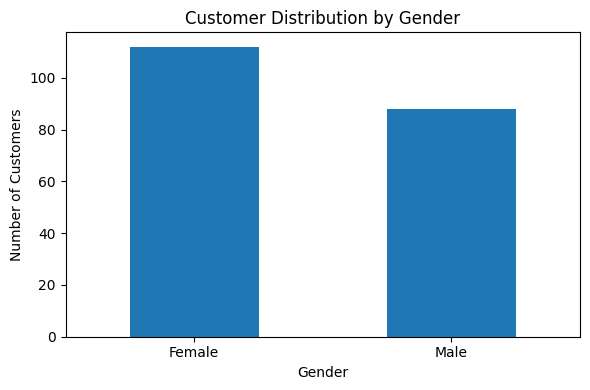

In [10]:
# Gender Distribution

gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 4))
gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

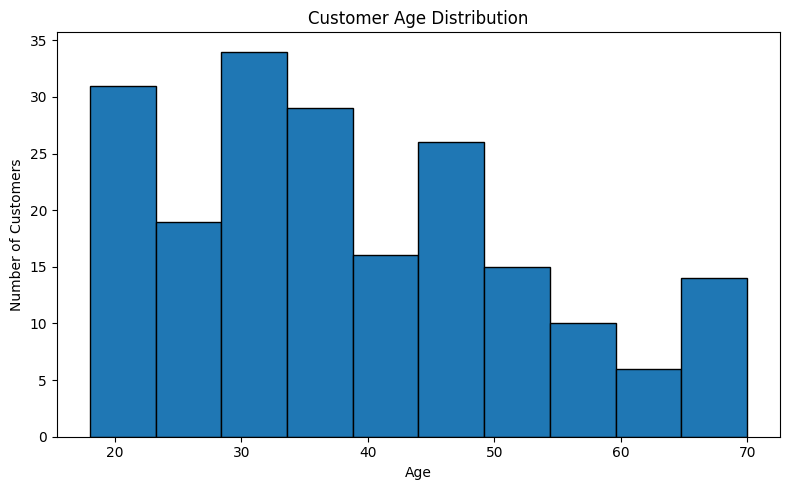

In [11]:
# Age Distribution

plt.figure(figsize=(8, 5))
plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

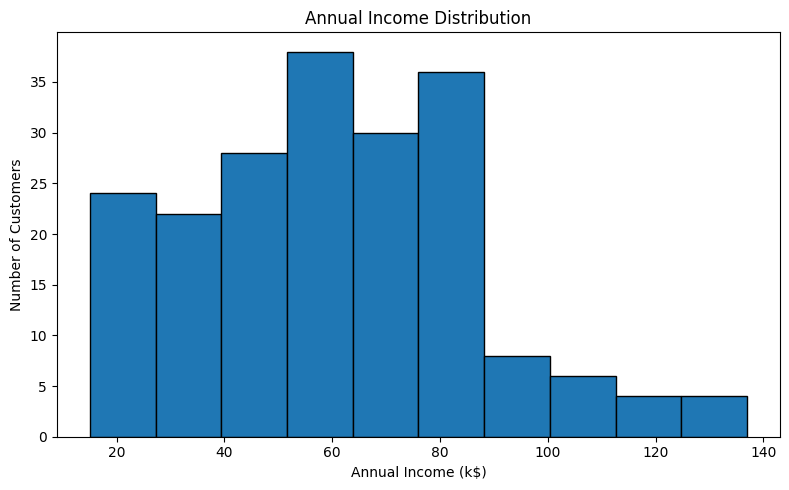

In [12]:
# Annual Income Distribution

plt.figure(figsize=(8, 5))
plt.hist(df["Annual Income (k$)"], bins=10, edgecolor="black")

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

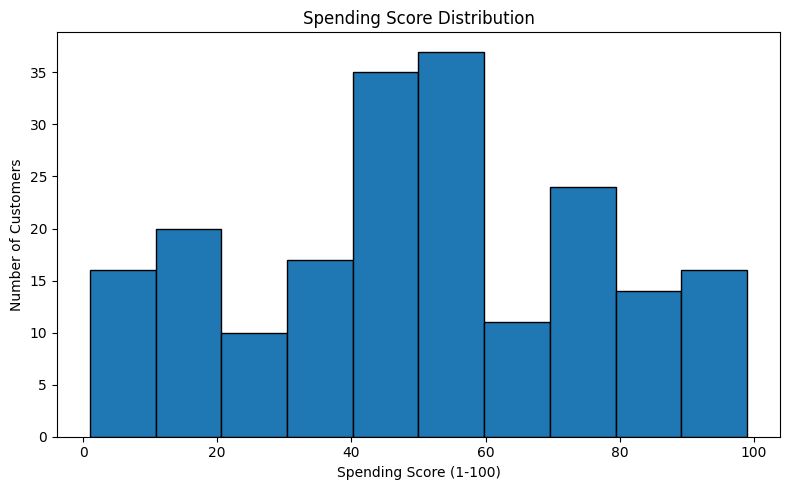

In [13]:
# Spending Score Distribution

plt.figure(figsize=(8, 5))
plt.hist(df["Spending Score (1-100)"], bins=10, edgecolor="black")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

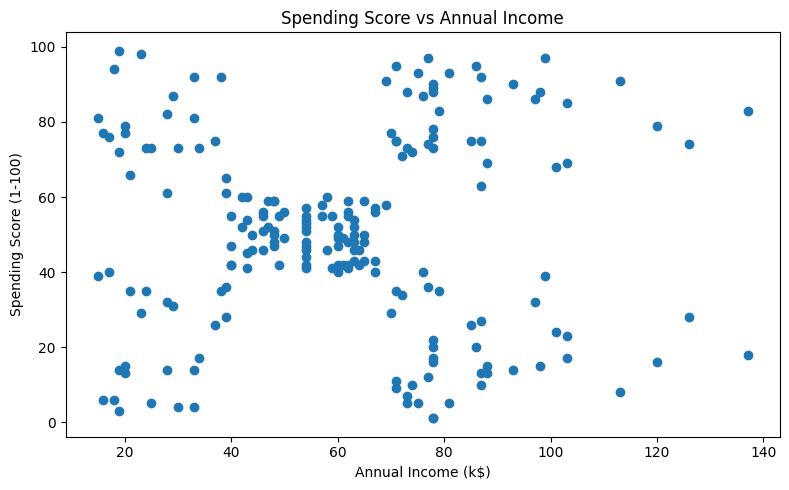

In [17]:
# Spending Score vs Annual Income

plt.figure(figsize=(8, 5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])

plt.title("Spending Score vs Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

In [18]:
# Customer Segmentation using K-Means

from sklearn.cluster import KMeans

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


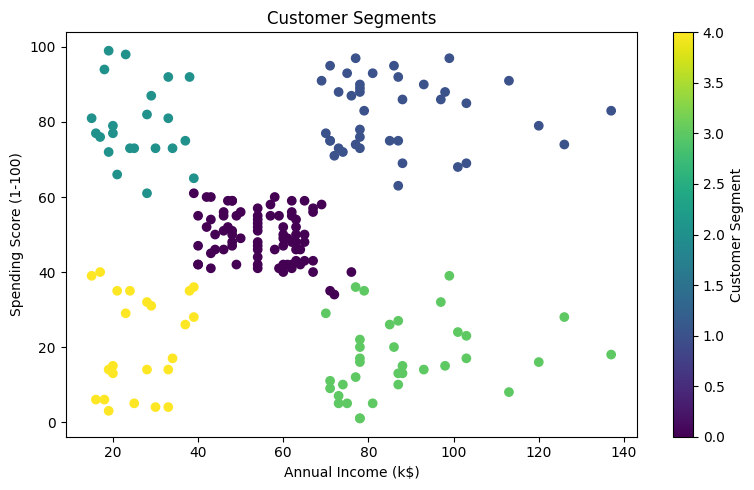

In [19]:
# Customer Segments Visualization

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(label="Customer Segment")

plt.tight_layout()
plt.show()

In [20]:
# Number of Customers in Each Segment

cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers in Each Segment:")
print(cluster_counts)

Customers in Each Segment:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [21]:
# Customer Segment Profile

segment_profile = df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

print("Customer Segment Profile:")
print(segment_profile.round(2))

Customer Segment Profile:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91


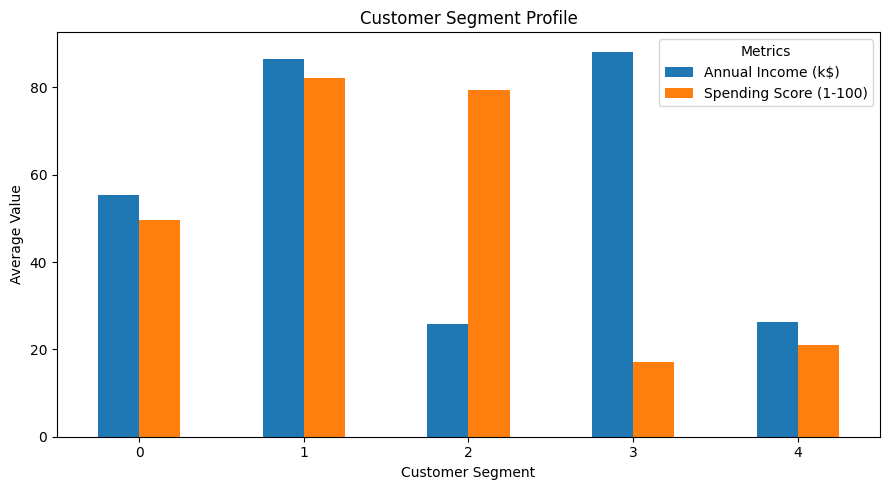

In [22]:
# Customer Segment Profile Visualization

segment_profile.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Segment Profile")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## Customer Segment Observations

- **Cluster 0:** Moderate-income customers with moderate spending scores.
- **Cluster 1:** High-income customers with high spending scores.
- **Cluster 2:** Lower-income customers with high spending scores.
- **Cluster 3:** High-income customers with low spending scores.
- **Cluster 4:** Lower-income customers with low spending scores.

These segments help businesses understand different customer groups and design targeted marketing strategies.

In [23]:
# Standardization for Clustering

from sklearn.preprocessing import StandardScaler

features = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Data standardized successfully.")
print(X_scaled[:5])

Data standardized successfully.
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


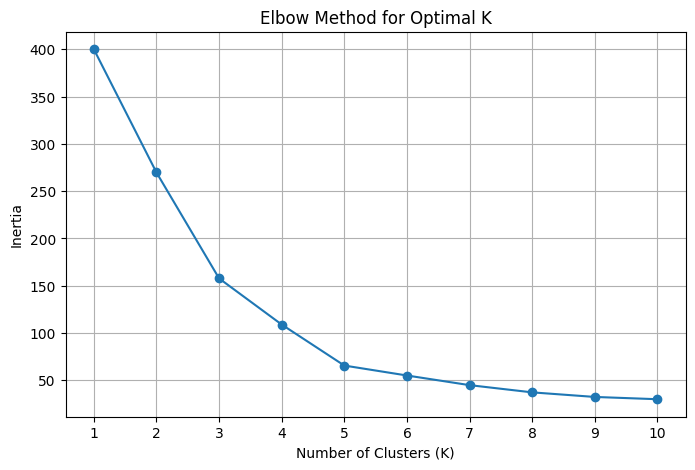

In [24]:
# Elbow Method to Find Optimal Number of Clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [26]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df["Customer_Segment"] = kmeans.fit_predict(X_scaled)

print("Customer segmentation completed.")
print(df["Customer_Segment"].value_counts().sort_index())

Customer segmentation completed.
Customer_Segment
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [28]:
# Customer Segment Profile

segment_profile = df.groupby("Customer_Segment")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

print("Customer Segment Profile:")
display(segment_profile)

Customer Segment Profile:


,Annual Income (k$),Spending Score (1-100)
Customer_Segment,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [29]:
# Assign meaningful names to customer segments

segment_names = {
    0: "Average Customers",
    1: "High Income - High Spending",
    2: "Low Income - High Spending",
    3: "High Income - Low Spending",
    4: "Low Income - Low Spending"
}

df["Segment_Name"] = df["Customer_Segment"].map(segment_names)

print("Customer Segment Names:")
print(df["Segment_Name"].value_counts())

Customer Segment Names:
Segment_Name
Average Customers              81
High Income - High Spending    39
High Income - Low Spending     35
Low Income - Low Spending      23
Low Income - High Spending     22
Name: count, dtype: int64


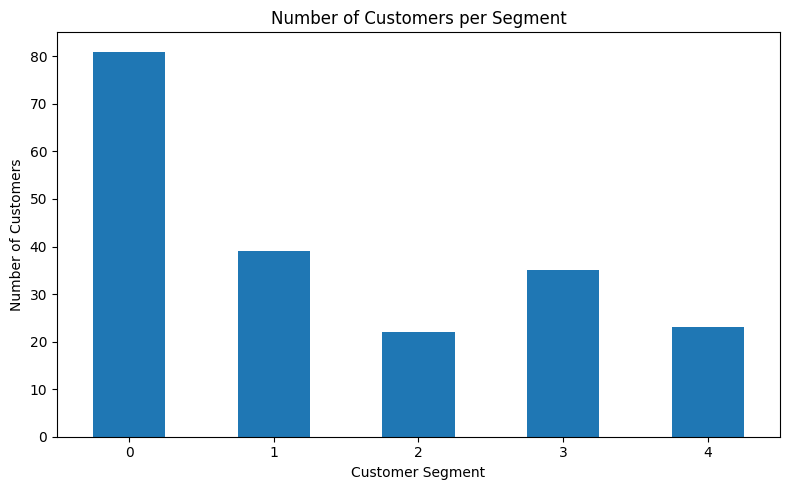

In [30]:
# Customer Count per Segment

plt.figure(figsize=(8, 5))

df["Customer_Segment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Number of Customers per Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Marketing Insights by Customer Segment

- **Segment 0:** Moderate-income customers with moderate spending behaviour. Suitable for regular promotions and loyalty offers.
- **Segment 1:** High-income and high-spending customers. Focus on premium products, personalized offers, and loyalty programs.
- **Segment 2:** Low-income but high-spending customers. Target with attractive discounts and value-based offers.
- **Segment 3:** High-income but low-spending customers. Use personalized campaigns and product recommendations to increase engagement.
- **Segment 4:** Low-income and low-spending customers. Focus on affordable products, discounts, and entry-level offers.

## Conclusion

Customer segmentation helps identify different customer groups based on their annual income and spending score. The analysis shows clear differences between customer segments, which can help businesses design more targeted marketing strategies.

## Business Recommendations

1. Offer premium products and loyalty programs to high-income, high-spending customers.
2. Provide discounts and value-based offers to customers with lower spending scores.
3. Use personalized marketing campaigns based on customer segment characteristics.